# Telecom Retention Campaign Targeting
### Who Do We Save, How, and When?

**Author:** Dexterfun  
**Date:** April 2026  
**Tools:** Python, Pandas, Seaborn, Scikit-learn

---

## Business Problem

Not all churners are worth saving — and not all at-risk customers need the same intervention.

This analysis goes beyond predicting churn. It answers the real question a retention manager asks:

> *"Given our at-risk customers, who should we call, who should we email, and who should we offer a discount?"*

---

## Objectives

1. Identify customers at high risk of churning
2. Segment them by **contract type, spend, and tenure**
3. Recommend a **targeted retention action** for each segment:
   - 📞 **Call** — high-value, long-tenure customers
   - 📧 **Email** — mid-tier, price-sensitive customers  
   - 🎁 **Offer a deal** — short-tenure, low-commitment customers

---

## Dataset
- **Source:** IBM Telco Customer Churn Dataset (via Kaggle)
- **Rows:** 7,043 customers
- **Target Variable:** `Churn` (Yes/No)

---

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load data
df = pd.read_csv(r'C:\Users\dexte\customer-churn-analysis\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

## 2. Data Exploration & Cleaning

In [3]:
# Basic info
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nChurn distribution:")
print(df['Churn'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Cleaning Notes
- `TotalCharges` is stored as a string — converting to numeric
- 26.5% of customers have churned (class imbalance noted)
- No null values detected, but `TotalCharges` contains whitespace entries

In [4]:
# Fix TotalCharges - convert to numeric (whitespace becomes NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the 11 rows with NaN TotalCharges
df.dropna(subset=['TotalCharges'], inplace=True)

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Cleaned dataset shape: {df.shape}")
print(f"\nChurn rate: {df['Churn'].mean():.1%}")

Cleaned dataset shape: (7032, 21)

Churn rate: 26.6%


---

## 3. Exploratory Data Analysis (EDA)

Before building a model, we need to understand *who* is churning.  
This shapes how we'll design our retention campaign segments later.

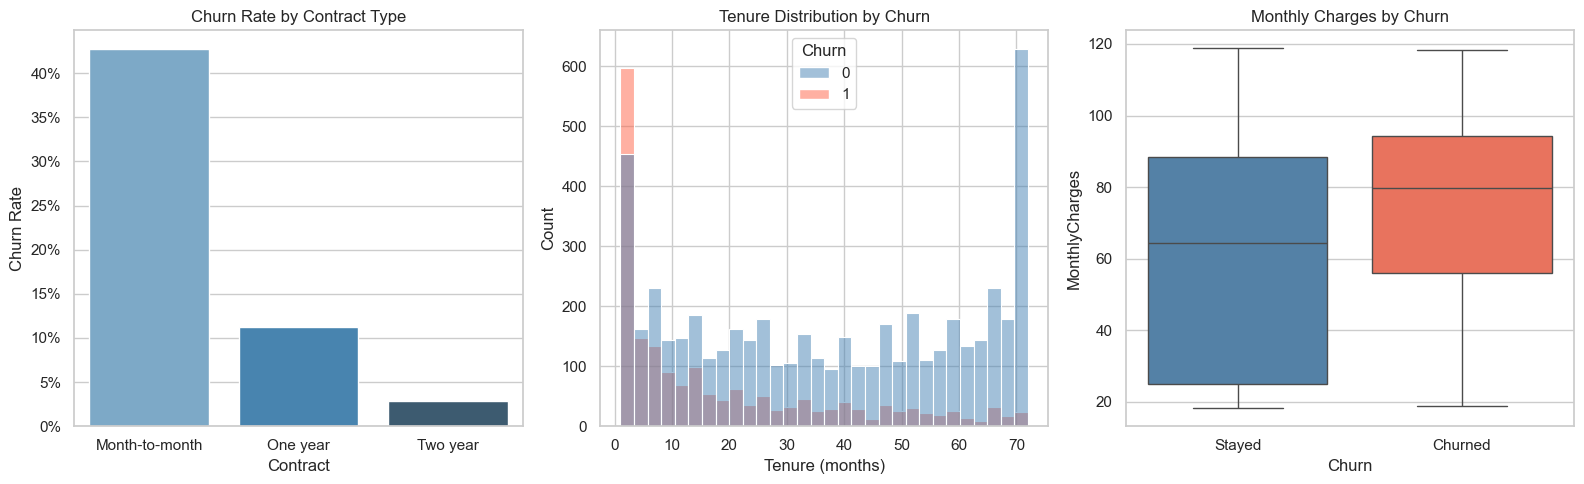

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Contract type vs Churn
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
sns.barplot(data=contract_churn, x='Contract', y='Churn', ax=axes[0], palette='Blues_d')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Tenure vs Churn
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, ax=axes[1], palette={0:'steelblue', 1:'tomato'})
axes[1].set_title('Tenure Distribution by Churn')
axes[1].set_xlabel('Tenure (months)')

# Monthly Charges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2], palette={'0':'steelblue', '1':'tomato'})
axes[2].set_title('Monthly Charges by Churn')
axes[2].set_xticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.savefig(r'C:\Users\dexte\customer-churn-analysis\visuals\eda_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 4. Feature Engineering & Model Preparation

We need to convert categorical columns to numbers before feeding them into our model.

In [9]:
# Drop customerID (not useful for prediction)
df_model = df.drop(columns=['customerID'])

# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

# One-hot encode multi-category columns
df_model = pd.get_dummies(df_model, columns=[
    'gender', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
])

# Define features and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Features: {X.shape[1]}")

Training set: (5625, 41)
Test set: (1407, 41)
Features: 41


---

## 5. Model Training & Evaluation

We use a Random Forest Classifier — it handles imbalanced data well and gives us
feature importances we can use to explain *why* customers churn.

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.89      0.86      1033
     Churned       0.62      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



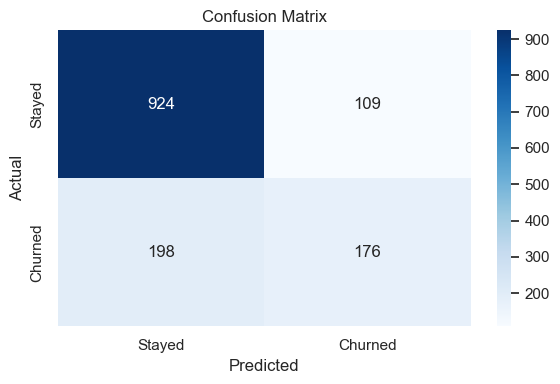

In [10]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
ax.set_title('Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(r'C:\Users\dexte\customer-churn-analysis\visuals\confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Performance Notes

| Metric | Stayed | Churned |
|--------|--------|---------|
| Precision | 82% | 62% |
| Recall | 89% | 47% |
| F1-Score | 86% | 53% |

**Overall Accuracy: 78%**

- The model is strong at identifying customers who *stay*
- It catches **47% of actual churners** — meaning we flag roughly 1 in 2 at-risk customers
- For a retention campaign, **recall matters most** — missing a churner is more costly than a false alarm
- Next step: use churn probability scores (not just Yes/No) to rank customers by risk level

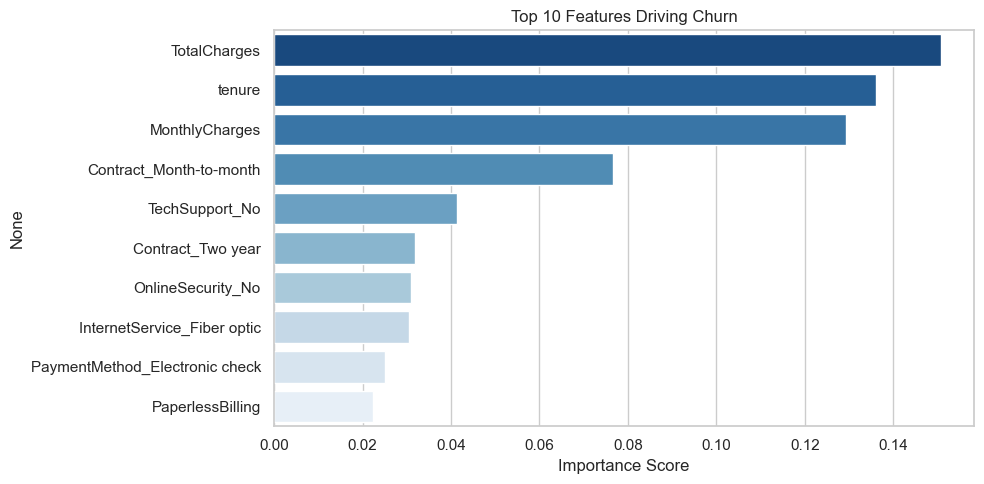

In [12]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r', ax=ax)
ax.set_title('Top 10 Features Driving Churn')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r'C:\Users\dexte\customer-churn-analysis\visuals\feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. Retention Campaign Targeting

Now we use churn probability scores to segment customers into three groups,
each requiring a different retention action.

| Risk Score | Segment | Action |
|------------|---------|--------|
| > 70% | High Risk | 📞 Call them |
| 40–70% | Medium Risk | 📧 Email them |
| < 40% | Low Risk | 🎁 Offer a deal |

In [13]:
# Get churn probabilities instead of just Yes/No
df_test = X_test.copy()
df_test['Churn_Actual'] = y_test.values
df_test['Churn_Probability'] = rf_model.predict_proba(X_test)[:, 1]

# Segment customers by risk
def assign_action(prob):
    if prob > 0.70:
        return '📞 Call'
    elif prob > 0.40:
        return '📧 Email'
    else:
        return '🎁 Offer a Deal'

df_test['Retention_Action'] = df_test['Churn_Probability'].apply(assign_action)

# Summary
print("Retention Campaign Segments:")
print(df_test['Retention_Action'].value_counts())
print(f"\nTotal customers to target: {(df_test['Churn_Probability'] > 0.40).sum()}")

Retention Campaign Segments:
Retention_Action
🎁 Offer a Deal    1025
📧 Email            259
📞 Call             123
Name: count, dtype: int64

Total customers to target: 382


### Campaign Segment Summary

Out of 1,407 test customers:

| Action | Count | Rationale |
|--------|-------|-----------|
| 📞 Call | 123 | Highest risk (>70%) — personal outreach needed |
| 📧 Email | 259 | Medium risk (40-70%) — nurture with targeted messaging |
| 🎁 Offer a Deal | 1,025 | Lower risk — proactive discount to prevent future churn |

**382 customers** are actively at risk and need immediate intervention.

> A retention call costs far less than acquiring a new customer.
> Even saving 30% of high-risk customers could significantly impact monthly revenue.

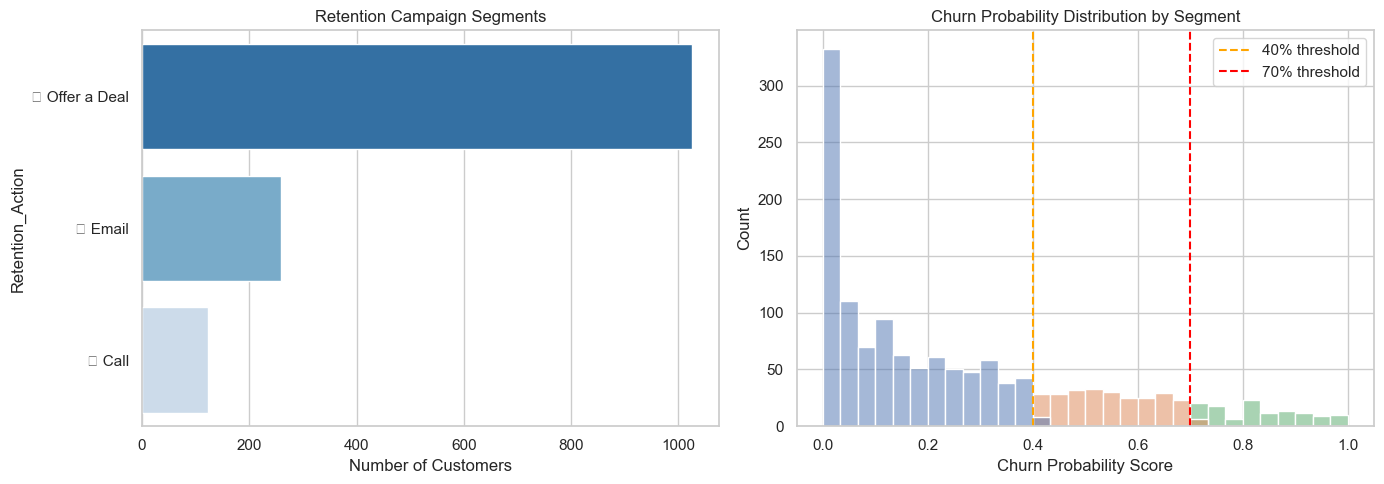

In [14]:
# Visualize campaign segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment distribution
segment_counts = df_test['Retention_Action'].value_counts()
sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Retention Campaign Segments')
axes[0].set_xlabel('Number of Customers')

# Churn probability distribution by segment
sns.histplot(data=df_test, x='Churn_Probability', hue='Retention_Action', bins=30, ax=axes[1])
axes[1].set_title('Churn Probability Distribution by Segment')
axes[1].set_xlabel('Churn Probability Score')
axes[1].axvline(x=0.40, color='orange', linestyle='--', label='40% threshold')
axes[1].axvline(x=0.70, color='red', linestyle='--', label='70% threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\dexte\customer-churn-analysis\visuals\retention_segments.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7. Business Recommendations

Based on our analysis, here are three actionable recommendations for the retention team:

### 1. 📞 Prioritize Personal Outreach for High-Risk Customers
- 123 customers have >70% churn probability
- These are likely month-to-month, high-spend customers in early tenure
- **Action:** Assign retention agents to call within 48 hours

### 2. 📧 Launch a Targeted Email Campaign for Medium-Risk Customers
- 259 customers sit in the 40–70% risk range
- **Action:** Send personalized emails highlighting loyalty rewards or contract upgrade benefits

### 3. 🎁 Proactive Discounts for Low-Risk but Price-Sensitive Customers
- Many low-risk customers are paying high monthly charges
- **Action:** Offer a 10–15% loyalty discount before they start shopping around

### Key Insight
> The most powerful churn predictor is **contract type**.  
> Converting month-to-month customers to annual contracts should be the #1 retention priority.